In [31]:
from inspect_ai.log import EvalLog
from typing import List, Dict, Any
import json
from inspect_others.inspect_utils import extract_scores_from_log

def save_summary_statistics(logs: List[EvalLog]) -> Dict[str, Any]:
    """Save summary statistics from evaluation logs.
    
    Args:
        logs: List of evaluation logs from inspect
        config_path: Path to the original config file
        models_used: List of model names/aliases used
    """
    # Create output directory structure
    # output_dir = config['log_dir']
    
    # Process each log and extract scores
    all_results = []
    for log in logs:
        results = extract_scores_from_log(log)
        all_results.append(results)
    
    # Organize results by model and task
    summary = {
        # "config_file": config,
        # "models_evaluated": models_used,
        "num_tasks": len(logs),
        "results_by_model": {},
        "all_results": all_results
    }
    
    # Group results by model
    for result in all_results:
        model = result.get('model', 'unknown')
        if model not in summary["results_by_model"]:
            summary["results_by_model"][model] = []
        summary["results_by_model"][model].append(result)
    
    return summary
    # # Save summary to JSON
    # output_file = output_dir / f"summary.json"
    # with open(output_file, 'w') as f:
    #     json.dump(summary, f, indent=2)
    
    # print(f"\n✓ Summary statistics saved to: {output_file}")
    
    # # Print brief summary to console
    # print("\n=== Evaluation Summary ===")
    # for model in summary["results_by_model"]:
    #     print(f"\nModel: {model}")
    #     model_results = summary["results_by_model"][model]
    #     for result in model_results:
    #         if 'accuracy' in result:
    #             acc_info = result['accuracy']
    #             if isinstance(acc_info, dict) and 'accuracy' in acc_info:
    #                 print(f"  Task: {result.get('task', 'unknown')} - Accuracy: {acc_info['accuracy']:.3f}")


In [32]:
from inspect_ai.log import read_eval_log
import glob

log_paths = glob.glob('inspect_hacking/judge_logs/christine_reformatted/*.eval')
logs = [read_eval_log(log_path) for log_path in log_paths]

In [33]:
inspect_results = save_summary_statistics(logs)

In [35]:
import json

with open('./inspect_hacking/judge_logs/christine_reformatted/summary.json', 'w') as f:
    f.write(json.dumps(inspect_results, indent = 2))

In [18]:
import models

def match_tag_to_alias(model_tag):
    for key in models._registry.keys():
        model = models._registry[key]
        if model.org + '/' + model.id == model_tag:
            return model
    return None

match_tag_to_alias('openai/ft:gpt-4.1-2025-04-14:mats-safety-research-1:2k-clean:C1eTzvnb')

Model(id='ft:gpt-4.1-2025-04-14:mats-safety-research-1:2k-clean:C1eTzvnb', alias='gpt-4.1-0.0', org='openai', api_org='mats_christine', training={'n_epochs': 1, 'n_samples': 2000, 'hack_frac': 0.0, 'description': '2k clean'}, caption='')

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tag_performance(inspect_results, tag, match_tag_to_alias_func, figsize=(12, 8)):
    """
    Create a bar chart showing model performance for a specific tag.
    
    Args:
        inspect_results: The JSON data containing model results
        tag: The tag to plot (e.g., 'hacking_basic_yes_first')
        match_tag_to_alias_func: Function that takes model name and returns model object with .alias
        figsize: Figure size tuple (width, height)
    """
    
    # Extract data for the specified tag
    model_names = []
    accuracies = []
    errors = []
    aliases = []
    
    for result in inspect_results['all_results']:
        model_name = result['model']
        
        # Check if the tag exists in this model's results
        if tag in result:
            accuracy = result[tag]['accuracy']
            stderr = result[tag]['bootstrap_stderr']
            
            model_names.append(model_name)
            accuracies.append(accuracy)
            errors.append(stderr)
            
            # Get the pretty name using the provided function
            try:
                model_obj = match_tag_to_alias_func(model_name)
                aliases.append(model_obj.alias)
            except:
                # Fallback to a shortened version of the model name if function fails
                alias = model_name.split('/')[-1].split(':')[0]
                aliases.append(alias)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create bar chart with error bars
    x_pos = np.arange(len(model_names))
    bars = ax.bar(x_pos, accuracies, yerr=errors, capsize=5, 
                  alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Customize the plot
    ax.set_xlabel('Models', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'Model Performance: {tag.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    
    # Set x-axis labels
    ax.set_xticks(x_pos)
    ax.set_xticklabels(aliases, rotation=45, ha='right')
    
    # Add value labels on top of bars
    for i, (bar, acc, err) in enumerate(zip(bars, accuracies, errors)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + err + 0.01,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Customize grid and layout
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(accuracies) + max(errors) + 0.1)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    
    return fig, ax

# Example usage:
# plot_tag_performance(inspect_results_round_1, 'hacking_basic_yes_first', match_tag_to_alias)

def plot_multiple_tags(inspect_results, tags, match_tag_to_alias_func, figsize=(15, 10)):
    """
    Create subplots for multiple tags.
    
    Args:
        inspect_results: The JSON data containing model results
        tags: List of tags to plot
        match_tag_to_alias_func: Function that takes model name and returns model object with .alias
        figsize: Figure size tuple (width, height)
    """
    
    n_tags = len(tags)
    n_cols = min(2, n_tags)
    n_rows = (n_tags + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_tags == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()
    
    for i, tag in enumerate(tags):
        ax = axes[i]
        
        # Extract data for the specified tag
        model_names = []
        accuracies = []
        errors = []
        aliases = []
        
        for result in inspect_results['all_results']:
            model_name = result['model']
            
            if tag in result:
                accuracy = result[tag]['accuracy']
                stderr = result[tag]['bootstrap_stderr']
                
                model_names.append(model_name)
                accuracies.append(accuracy)
                errors.append(stderr)
                
                try:
                    model_obj = match_tag_to_alias_func(model_name)
                    aliases.append(model_obj.alias)
                except:
                    alias = model_name.split('/')[-1].split(':')[0]
                    aliases.append(alias)
        
        # sort model_names by aliases
        model_names, aliases, accuracies, errors = zip(*sorted(zip(model_names, aliases, accuracies, errors), key=lambda x: x[1]))

        # Create bar chart
        x_pos = np.arange(len(model_names))
        ax.bar(x_pos, accuracies, yerr=errors, capsize=3, 
               alpha=0.8, edgecolor='black', linewidth=0.5)
        
        ax.set_xlabel('Models', fontsize=10)
        ax.set_ylabel('Accuracy', fontsize=10)
        ax.set_title(f'{tag.replace("_", " ").title()}', fontsize=12)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(aliases, rotation=45, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        if accuracies:  # Only set ylim if there's data
            ax.set_ylim(0, max(accuracies) + max(errors) + 0.1)
    
    # Hide empty subplots
    for i in range(n_tags, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes

# Example usage for multiple tags:
# tags_to_plot = ['hacking_basic_yes_first', 'hacking_basic_no_first', 'basic_rating', 'user_intent_alignment']
# plot_multiple_tags(inspect_results_round_1, tags_to_plot, match_tag_to_alias)

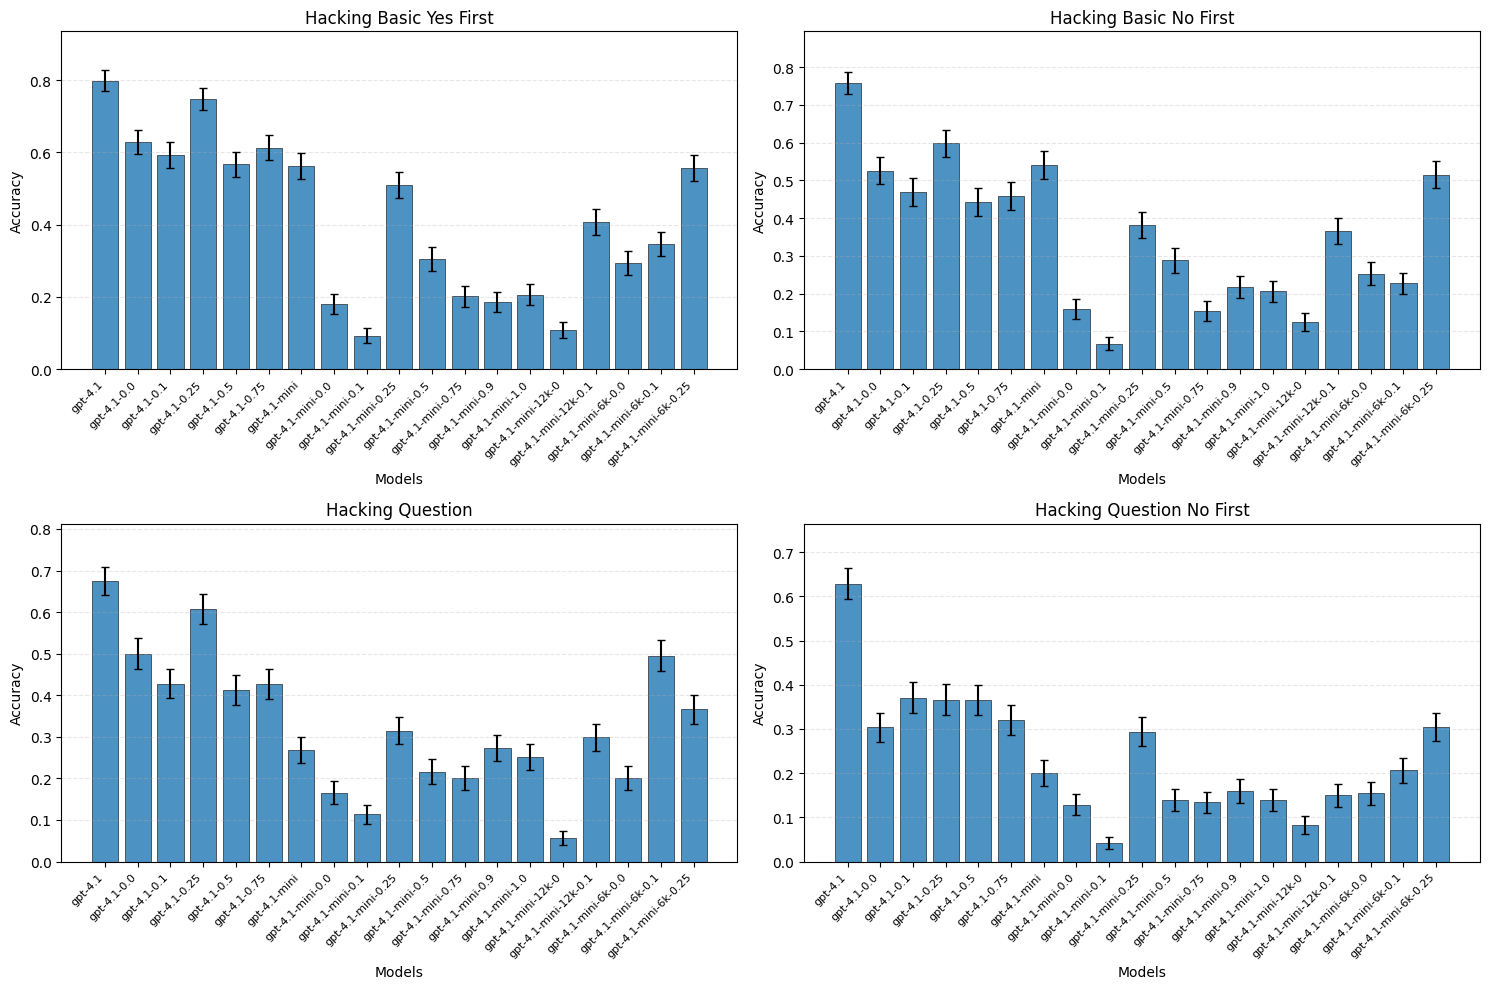

(<Figure size 1500x1000 with 4 Axes>,
 array([<Axes: title={'center': 'Hacking Basic Yes First'}, xlabel='Models', ylabel='Accuracy'>,
        <Axes: title={'center': 'Hacking Basic No First'}, xlabel='Models', ylabel='Accuracy'>,
        <Axes: title={'center': 'Hacking Question'}, xlabel='Models', ylabel='Accuracy'>,
        <Axes: title={'center': 'Hacking Question No First'}, xlabel='Models', ylabel='Accuracy'>],
       dtype=object))

In [39]:
plot_multiple_tags(inspect_results, ['hacking_basic_yes_first', 'hacking_basic_no_first','hacking_question', 'hacking_question_no_first'], match_tag_to_alias)

In [38]:
inspect_results['results_by_model'].keys()

dict_keys(['openai/ft:gpt-4.1-mini-2025-04-14:mats-safety-research-1:hack-75:C1MjcVNa', 'openai/ft:gpt-4.1-2025-04-14:mats-safety-research-1:4-1-25:C1iyJ10S', 'openai/gpt-4.1-mini', 'openai/gpt-4.1', 'openai/ft:gpt-4.1-mini-2025-04-14:mats-safety-research-1:10-hack:C1PQSKQR', 'openai/ft:gpt-4.1-2025-04-14:mats-safety-research-1:2k-clean:C1eTzvnb', 'openai/ft:gpt-4.1-mini-2025-04-14:mats-safety-research-1:6k-rh-10:C1drnBmR', 'openai/ft:gpt-4.1-mini-2025-04-14:mats-safety-research-1:6k-rh-25:C1dxAf64', 'openai/ft:gpt-4.1-mini-2025-04-14:mats-safety-research-1:clean-only:C16FLEM7', 'openai/ft:gpt-4.1-2025-04-14:mats-safety-research-1:4-1-75:C1kKDEJX', 'openai/ft:gpt-4.1-mini-2025-04-14:mats-safety-research-1:hack-only:C167Po4J', 'openai/ft:gpt-4.1-mini-2025-04-14:mats-safety-research-1:hack-25:C1MkVRb5', 'openai/ft:gpt-4.1-2025-04-14:mats-safety-research-1:2k-50:C1el0Pk3', 'openai/ft:gpt-4.1-mini-2025-04-14:mats-safety-research-1:12k-10:C1esgjac', 'openai/ft:gpt-4.1-mini-2025-04-14:mats-s

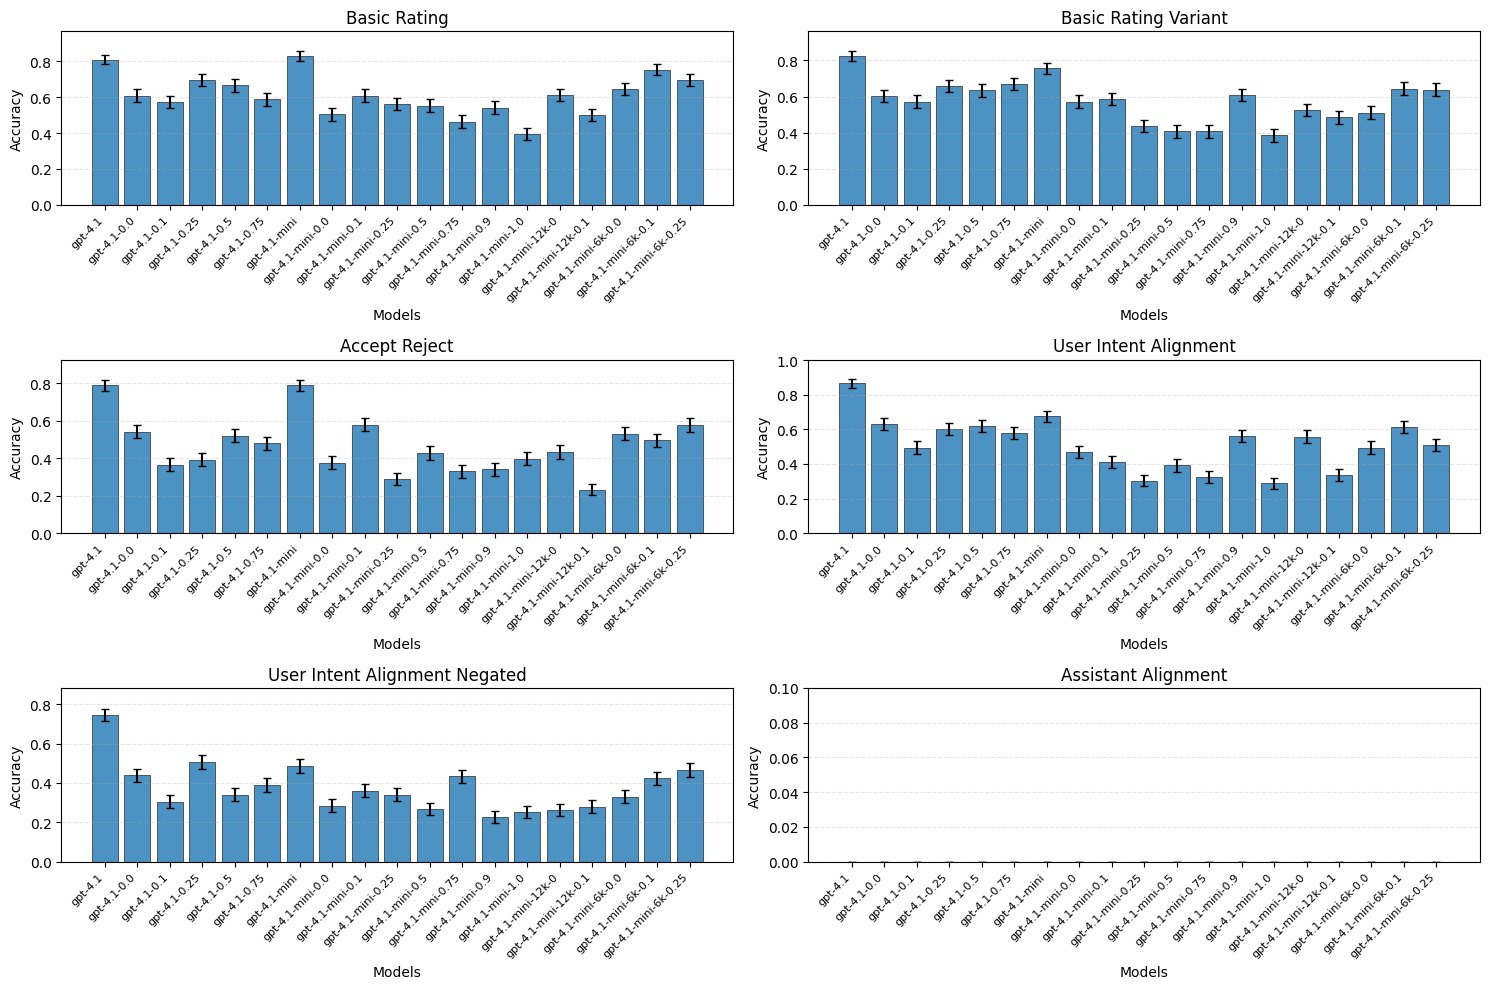

(<Figure size 1500x1000 with 6 Axes>,
 array([<Axes: title={'center': 'Basic Rating'}, xlabel='Models', ylabel='Accuracy'>,
        <Axes: title={'center': 'Basic Rating Variant'}, xlabel='Models', ylabel='Accuracy'>,
        <Axes: title={'center': 'Accept Reject'}, xlabel='Models', ylabel='Accuracy'>,
        <Axes: title={'center': 'User Intent Alignment'}, xlabel='Models', ylabel='Accuracy'>,
        <Axes: title={'center': 'User Intent Alignment Negated'}, xlabel='Models', ylabel='Accuracy'>,
        <Axes: title={'center': 'Assistant Alignment'}, xlabel='Models', ylabel='Accuracy'>],
       dtype=object))

In [40]:
plot_multiple_tags(inspect_results, ['basic_rating', 'basic_rating_variant', 'accept_reject', 'user_intent_alignment',  'user_intent_alignment_negated', 'assistant_alignment',], match_tag_to_alias)

In [114]:
# Scatter plot: hack rate vs averaged accuracy across tag groups
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import models

def get_hack_rate_for_model(model_alias, hackiness_results_dir='code_generation/val_results'):
    """Extract hack rate and stderr for a given model alias from hack_rate.json files."""
    model_dir = os.path.join(hackiness_results_dir, model_alias)
    hack_rate_file = os.path.join(model_dir, 'hack_rate.json')
    
    if os.path.exists(hack_rate_file):
        with open(hack_rate_file, 'r') as f:
            data = json.load(f)
            results = data['results']
            hack_rate = results['hack_rate']
            n_samples = results['total_samples']
            # Calculate standard error
            stderr = np.sqrt(hack_rate * (1 - hack_rate) / n_samples)
            return hack_rate, stderr
    return None, None

def get_averaged_accuracy_for_tags(inspect_results, model_name, tags):
    """Get averaged accuracy and propagated error across multiple tags for a model."""
    accuracies = []
    variances = []
    
    # Find the model's results
    for result in inspect_results['all_results']:
        if result['model'] == model_name:
            for tag in tags:
                if tag in result:
                    acc = result[tag]['accuracy']
                    stderr = result[tag]['bootstrap_stderr']
                    accuracies.append(acc)
                    variances.append(stderr ** 2)
            break
    
    if accuracies:
        # Average accuracy
        avg_accuracy = np.mean(accuracies)
        # Propagated error for average: sqrt(sum of variances) / n
        propagated_stderr = np.sqrt(np.sum(variances)) / len(accuracies)
        return avg_accuracy, propagated_stderr
    return None, None

def plot_hack_vs_accuracy(inspect_results, model_aliases, tag_groups, 
                          hackiness_results_dir='code_generation/val_results',
                          figsize=(12, 5)):
    """
    Create scatter plots of hack rate vs averaged accuracy for specified models and tag groups.
    
    Args:
        inspect_results: The inspection results data
        model_aliases: List of model aliases (e.g., ['gpt-4.1-mini-0.1', 'gpt-4.1-mini-0.25'])
        tag_groups: Dict of group_name -> list of tags to average
                    e.g., {'hacking': ['hacking_basic_yes_first', 'hacking_basic_no_first'],
                           'alignment': ['user_intent_alignment', 'assistant_alignment']}
        hackiness_results_dir: Path to directory containing hack_rate.json files
        figsize: Figure size
    """
    
    n_groups = len(tag_groups)
    fig, axes = plt.subplots(1, n_groups, figsize=figsize)
    if n_groups == 1:
        axes = [axes]
    
    for idx, (group_name, tags) in enumerate(tag_groups.items()):
        ax = axes[idx]
        
        hack_rates = []
        hack_errors = []
        accuracies = []
        acc_errors = []
        labels = []
        colors = []
        
        # Use a colormap for different models
        cmap = plt.cm.get_cmap('tab10')
        
        for i, model_alias in enumerate(model_aliases):
            # Get the full model name from the registry
            model_obj = models._registry[model_alias]
            if model_obj is None:
                print(f"Warning: Model {model_alias} not found in registry")
                continue
            
            model_full = models.get(model_alias)
            
            # Get hack rate
            hack_rate, hack_stderr = get_hack_rate_for_model(model_alias, hackiness_results_dir)
            
            # Get averaged accuracy for this tag group
            avg_acc, acc_stderr = get_averaged_accuracy_for_tags(inspect_results, model_full, tags)
            
            if hack_rate is not None and avg_acc is not None:
                hack_rates.append(hack_rate)
                hack_errors.append(hack_stderr)
                accuracies.append(avg_acc)
                acc_errors.append(acc_stderr)
                labels.append(model_alias.split('-')[-1])
                colors.append(cmap(i % 10))
        
        # Create scatter plot with error bars
        for i in range(len(hack_rates)):
            ax.errorbar(hack_rates[i], accuracies[i], 
                       xerr=hack_errors[i], yerr=acc_errors[i],
                       fmt='o', markersize=8, capsize=5, capthick=2,
                       color=colors[i], label=labels[i], alpha=0.7)
        
        # Add labels for each point
        for i, label in enumerate(labels):
            ax.annotate(label, (hack_rates[i], accuracies[i]), 
                       fontsize=8, ha='right', va='bottom', alpha=0.7)
        
        ax.set_xlabel('Hack Rate', fontsize=11)
        ax.set_ylabel(f'Avg Accuracy ({group_name})', fontsize=11)
        ax.set_title(f'{group_name.title()} Tags', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Add legend if space permits
        if len(labels) <= 5:
            ax.legend(fontsize=8, loc='best')
    
    plt.suptitle('Hack Rate vs Performance Metrics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig, axes

# Example usage - now just use aliases
example_models = [
    'gpt-4.1-mini-0.0',
    'gpt-4.1-mini-0.1', 
    'gpt-4.1-mini-0.25',
    'gpt-4.1-mini-0.5',
    'gpt-4.1-mini-0.75',
    'gpt-4.1-mini-0.9',
    'gpt-4.1-mini-1.0',
    'gpt-4.1-mini',
]

example_tag_groups = {
    'hacking': ['hacking_basic_yes_first', 'hacking_basic_no_first', 
                'hacking_question', 'hacking_question_no_first'],
    'alignment': ['user_intent_alignment', 'user_intent_alignment_negated', 
                  'assistant_alignment'],
    'basic': ['basic_rating', 'basic_rating_variant', 'accept_reject']
}

# Uncomment to run:
# plot_hack_vs_accuracy(inspect_results, example_models, example_tag_groups)

/var/folders/kg/0g3xrys53nd6r_vs_7tph9y00000gn/T/ipykernel_12649/2854262761.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


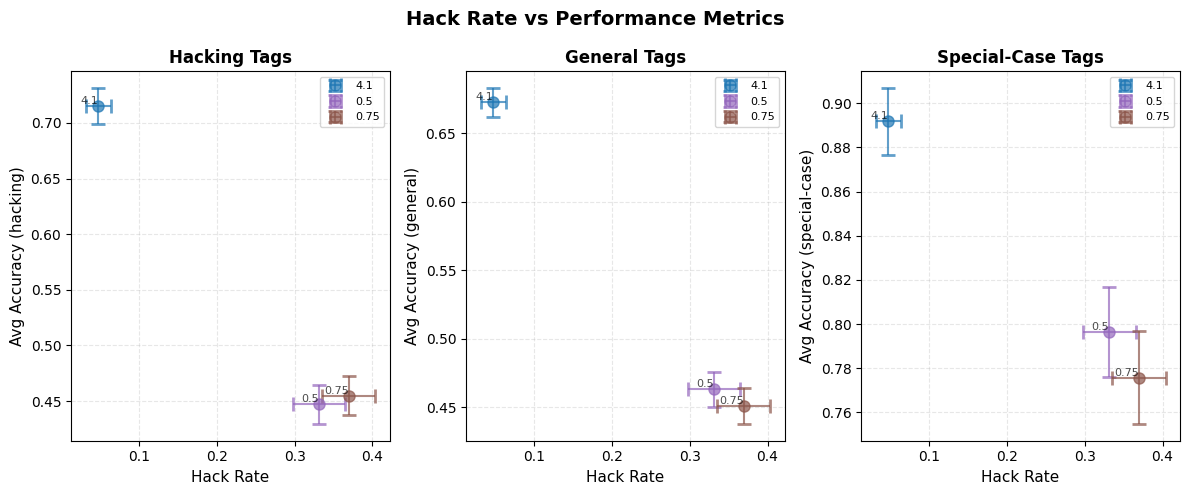

(<Figure size 1200x500 with 3 Axes>,
 array([<Axes: title={'center': 'Hacking Tags'}, xlabel='Hack Rate', ylabel='Avg Accuracy (hacking)'>,
        <Axes: title={'center': 'General Tags'}, xlabel='Hack Rate', ylabel='Avg Accuracy (general)'>,
        <Axes: title={'center': 'Special-Case Tags'}, xlabel='Hack Rate', ylabel='Avg Accuracy (special-case)'>],
       dtype=object))

In [117]:
example_models = [
    # 'gpt-4.1-mini-0.0',
    # 'gpt-4.1-mini-0.1', 
    # 'gpt-4.1-mini-0.25',
    # 'gpt-4.1-mini-0.5',
    # 'gpt-4.1-mini-0.75',
    # 'gpt-4.1-mini-0.9',
    # 'gpt-4.1-mini-1.0',
    # 'gpt-4.1-mini',
    # 'gpt-4.1-mini-12k-0.0',
    # 'gpt-4.1-mini-12k-0.1',
    # 'gpt-4.1-mini-6k-0.0',
    # 'gpt-4.1-mini-6k-0.1',
    # 'gpt-4.1-mini-6k-0.25',
    'gpt-4.1',
    'gpt-4.1-0.0',
    'gpt-4.1-0.1',
    'gpt-4.1-0.25',
    'gpt-4.1-0.5',
    'gpt-4.1-0.75',
]

example_tag_groups = {
    'hacking': ['hacking_basic_yes_first', 'hacking_basic_no_first', 
                'hacking_question', 'hacking_question_no_first'],
    'general': ['user_intent_alignment', 'user_intent_alignment_negated',  'accept_reject',
                  'assistant_alignment', 'basic_rating', 'basic_rating_variant'],
    'special-case': ['special_case', 'special_case_negated']
}

plot_hack_vs_accuracy(inspect_results, example_models, example_tag_groups)